In [3]:
# ## '''Installation'''
# !pip install qiskit[visualization]
# # Use the following if you are on MacOS/zsh
# #!pip install 'qiskit[visualization]'==1.1.0
# !pip install qiskit_aer
# !pip install qiskit_ibm_runtime
# !pip install matplotlib
# !pip install pylatexenc
# !pip install prototype-zne

# 1-D Schrodinger equation
 Schrodinger equation:
$$-i\hbar \frac{d \ket{\psi}}{dt} = H \ket{\psi}  $$

The Hamiltonian H of the system is:
$$T+V = \frac{p^2}{2m} + V$$
where p is momentum operator, V is potential operator and K is Kinetic Energy operator.

Its evolution is given by equation: $$|\psi(x,t)\rangle =  e^{-iHt} |\psi(x,0)\rangle$$

The unitary operator is $U=e^{-iHt}$



## Trotterization of Hamiltonian H

T and V are non commuting operators, i,e $[T,V]\neq 0$

Hence, Hamiltonian H need to be decomposed using trotterization

### Lie Trotter Method
$$e^{i(A+B)n\Delta t} \approx (e^{iA\Delta t} e^{iB\Delta t})^n $$
Lie-Trotter decomposition of H
$$
U =e^{-i\hat{H}t} \approx \left(e^{-i\hat{T}\Delta t} e^{-\hat{V}\Delta t}\right)^n
$$


<!-- <details>
<summary>Lie-Trotter decomposition of H  </summary>

inside text
</details> -->

### Suzuki Trotter Method
$$e^{i(A+B)n\Delta t} \approx (e^{i\frac{A}{2}\Delta t} e^{iB\Delta t} e^{i\frac{A}{2}\Delta t})^n $$
Suzuki-Trotter decomposition of H

$$e^{-i\hat{H}t/\hbar} \approx  \left( e^{-i\hat{V} \Delta t/2} e^{-iT\Delta t} e^{-i\hat{V} \Delta t/2} \right)^n
$$
<!-- <details>
<summary> Suzuki-Trotter decomposition of H</summary>
inside text
</details> -->
Since $\hat{T}=\frac{\hat{p}^2 }{2m}$ which is in momentum space, for applying operator T, the  basis need to be transformed to momentum space and revert back to computation space after applying the gate. We can achieve by using Fourier Transform: Quantum Fourier transform for quantum computers. So the operation would become:

$$e^{-i\hat{V} \Delta t/2} QFT e^{-iT\Delta t} QFT_{inv} e^{-i\hat{V} \Delta t/2}$$


We have $\hat{T} = \frac{\hat{p}^2 }{2 }$(let m=1 for simplicity), we can write $\hat{p}$ as :
$$
\hat{p} = -\sqrt{\frac{1}{2^{2n-3} } \frac{\phi}{\Delta t}} \left(1 + \sum_{j=1}^{n} 2^{n-j} \hat{Z_j}\right)
$$


Ref: Eltohfa, M. (2021). Quantum Simulation of Schrödinger's Equation

The whole equation $e^{i\hat{p}^2\Delta t}$ becomes
$$
e^{i\hat{p}^2\Delta t} = exp\left(\frac{i\phi}{2^{2n-3}} \left(1 + \sum_{j=1}^{n} 2^{n-j} \hat{Z_{j}}\right)^2\right)
$$


## For Particle in a Box with Potential V
$$U = e^{-iV\Delta t }QFT e^{-iT\Delta t} QFT_{inv} $$



In [15]:
# import of required libraries and modules
from math import pi
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.visualization import plot_histogram, plot_distribution
from qiskit.circuit.library import QFTGate as QFT
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator

### Initial wavefunction
For now, We will be working on a Gaussian stationary wavefunction with no initial kinetic energy $k_0=0$:
$$\psi(x,t_{0}) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-x_{0}}{\sigma}\right)^{2}} e^{i\hbar k_{0}x}$$

Since $k_0=0$, we can exclude the last term and $\psi$ becomes:
$$\psi(x,t_{0}) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-x_{0}}{\sigma}\right)^{2}}$$

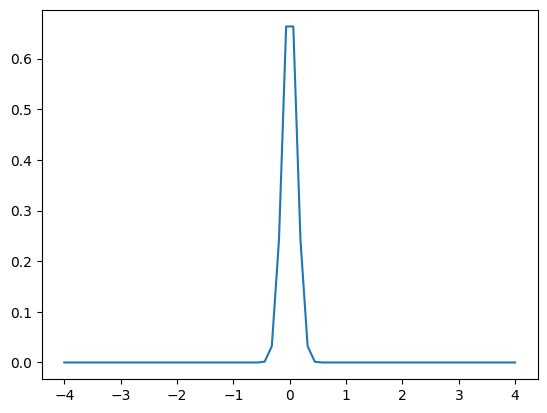

In [16]:
# Preparing the Gaussian-shaped histogram that will be used in the initialisation

x = np.linspace(-4,4, num=64)
x0=0


'''wavefunction: guassian wavepacket'''
pos=0
unnormalized_wavefunction = (1/(np.sqrt(2*np.pi)*0.4)*np.exp(-(0.5*(x-x0)**2)/(0.016)))


Normalisation_Constant = np.sqrt(np.sum(np.abs(unnormalized_wavefunction**2)))

wavefunction = (unnormalized_wavefunction)/(Normalisation_Constant)


plt.plot(x,wavefunction)
plt.show()


In [17]:
# sampler = StatevectorSampler()
def initialization(qc,wavefunction,q_reg):

    qc.initialize(wavefunction, q_reg)

def apply_QFT(qc,q_reg,n):
    qc.append(QFT(num_qubits=n), q_reg)


def Time_Evolution(qc,n,q_reg,aux_reg):
    # qc=QuantumCircuit(q_reg,aux_reg)
    for i in range (n):
        qc.p(phi/(2**(i+n-3)),q_reg[n-i-1])
    for i in range (n):
        for j in range (i+1,n):
            qc.cx(q_reg[n-j-1], aux_reg[0])
            qc.cx(q_reg[n-i-1], aux_reg[0])
            qc.p(phi* (2**(2-i-j)), aux_reg[0]) 
            qc.cx(q_reg[n-i-1], aux_reg[0])
            qc.cx(q_reg[n-j-1], aux_reg[0])
            # qc.barrier()
    # qc.to_gate()


def apply_invQFT(qc,q_reg,n):
    qc.append(QFT(num_qubits=n).inverse(), q_reg)


def display_histogram(qc, q_reg, c_reg, n, plot=False, hist=True, backend=AerSimulator(), shots=4096, probabilities=False):
    qc.measure(q_reg,clas_reg)
    keys = range(0,2**n)
    counts= {key: 0 for key in keys}
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    transpiled_qc = pm.run(qc)
    sampler = Sampler(backend)
    job = sampler.run([transpiled_qc], shots=shots)
    result = job.result()[0]
    raw_counts = result.data.classical.get_counts()
    
    # Convert binary string keys to integers to match the x-axis
    formatted_counts = {int(k, 2): v for k, v in raw_counts.items()}
    
    # Fill in missing values for the full range 0-63
    full_counts = {i: formatted_counts.get(i, 0) for i in range(2**n)}

    probabilities = {i: formatted_counts.get(i, 0) /shots for i in range(2**n)}
    
    if hist:
        if probabilities:
            fig = plot_histogram(probabilities,bar_labels=False,figsize=(10, 5))
            ax = fig.axes[0]
            # ax.set_ylim(0, 0.5)   # 👈 FIXED y-axis
            display(fig)

            # display(plot_histogram(probabilities, bar_labels=False,figsize=(10,5),) )
        else:
            display(plot_histogram(full_counts, bar_labels=False,figsize=(10,5)))
      
    if plot:
        plt.figure(figsize=(10, 5))
        if probabilities:
            plt.plot(list(probabilities.keys()), list(probabilities.values()))
            # plt.ylim(0, 0.5)
            plt.title("Wavefunction Probability Distribution")
            plt.xlabel("State Index")
            plt.ylabel("Probability")
            plt.show()
            return
        else:
            plt.plot(list(full_counts.keys()), list(full_counts.values()))
            plt.title("Wavefunction Probability Distribution")
            plt.xlabel("State Index")
            plt.ylabel("Probability")
            plt.show()
        
        

    # return full_counts

    # qc_counts= job.result()[0].data.classical.get_counts()
    # for key, value in qc_counts.items():
    #     if key in counts:
    #         counts[key] = value*100
    # keys = list(counts.keys())
    # values = list(counts.values())
    # if plot:
    #     plt.plot(keys,values)
    # if hist:
    #     display(plot_histogram(counts,bar_labels=False))


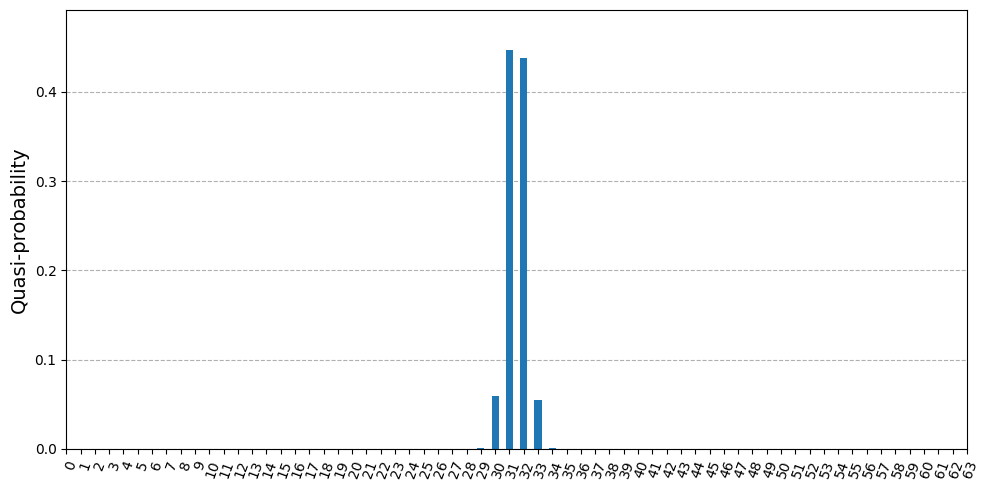

In [18]:
# Setting up the quantum circuit
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.visualization import plot_histogram
backend = AerSimulator()
phi = 0.3  # function of time step
n=6
q_reg=QuantumRegister(6)
aux_reg=QuantumRegister(1)
clas_reg = ClassicalRegister(6,'classical')
qc=QuantumCircuit(aux_reg,q_reg,clas_reg)
initialization(qc,wavefunction,q_reg)

initial_qc=qc.copy()
#display histogram for initial state
display_histogram(initial_qc, q_reg, clas_reg, n, hist=True)
# initial_qc.measure(q_reg, clas_reg)

# pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
# initial_pm_circuit = pm.run(initial_qc)
# sampler = Sampler(backend)
# job = sampler.run([initial_pm_circuit])
# result = job.result()

# print(result)
# plot_histogram(result[0].data.classical.get_counts())
# Get quasi distribution from result


In [9]:

# write a code for first iteration: Initialization->QFT->KE operator->inverse QFT



# apply_QFT(qc,q_reg,n)
# qc.x(qb) # Applying potential barrier at the center
# Time_Evolution(qc,n,q_reg,aux_reg)
# qc.x(qb) # Applying potential barrier at the center
# apply_invQFT(qc,q_reg,n)
# qc.draw(fold=-1)
# # iter1=qc.copy()
# # display_histogram(iter1,q_reg,clas_reg)


## Free particle Travelling Forward

In [ ]:
x = np.linspace(-0.5,4, num=64)
'''wavefunction: guassian wavepacket with moving forward(+ve x axis) in time'''
x0=0
hk=-3
V=1.75
unnormalized_wavefunction= (1/(np.sqrt(2*np.pi)*0.4)*np.exp(-(0.5*(x-x0)**2)/(0.016)))*np.exp(300j*x)


Normalisation_Constant = np.sqrt(np.sum(np.abs(unnormalized_wavefunction**2)))

forward_wave = (unnormalized_wavefunction)/(Normalisation_Constant)


# plt.plot(x,forward_wave)
# plt.show()
def evolve(iter,wavefunction,n=6,plot=True,hist=True):
    phi = 0.1  # function of time step
    V=1.5
    q_reg=QuantumRegister(6)
    aux_reg=QuantumRegister(1)
    clas_reg = ClassicalRegister(6,'classical')
    qc=QuantumCircuit(aux_reg,q_reg,clas_reg)
    initialization(qc,forward_wave,q_reg)
    i=0
    snaps=[]
    for i in range(iter):
        # qc.p(V*phi,n)

        # qc.ccx(4,3,0)
        # qc.cp(V*phi,0,5)
        # qc.ccx(4,3,0)

        # qc.cx(4,0)
        # qc.cp(V*phi,0,5)
        # qc.cx(4,0)

        apply_QFT(qc,q_reg,n) 
        qc.x(n)
        Time_Evolution(qc,n,q_reg,aux_reg)
        qc.x(n) 
        apply_invQFT(qc,q_reg,n)
        if i%2==0:
            snaps.append(qc.copy())
        i=i+1
    for snap in snaps:
        display_histogram(snap,q_reg,clas_reg,n,plot=plot,hist=hist,probabilities=True)


evolve(iter=100,wavefunction=forward_wave,n=6,plot=False,hist=True)

## Step Potential

V is at qubit n=4

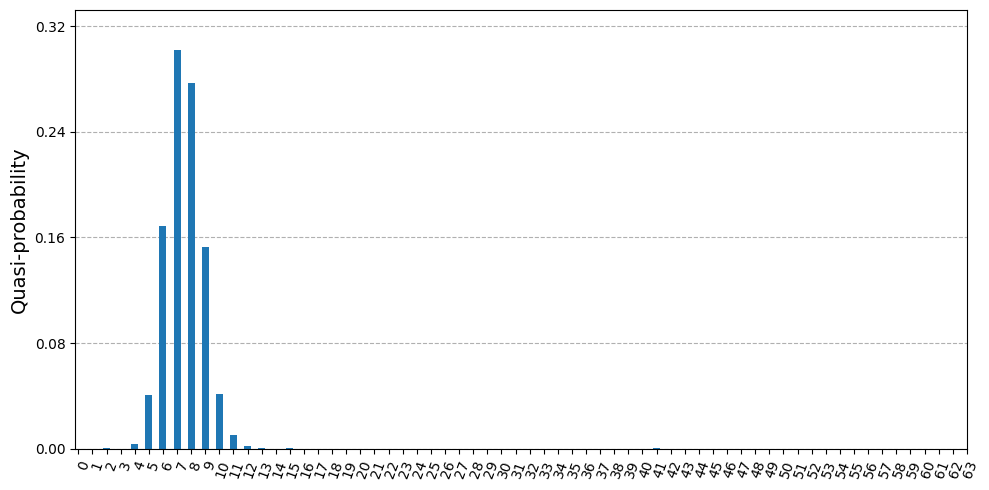

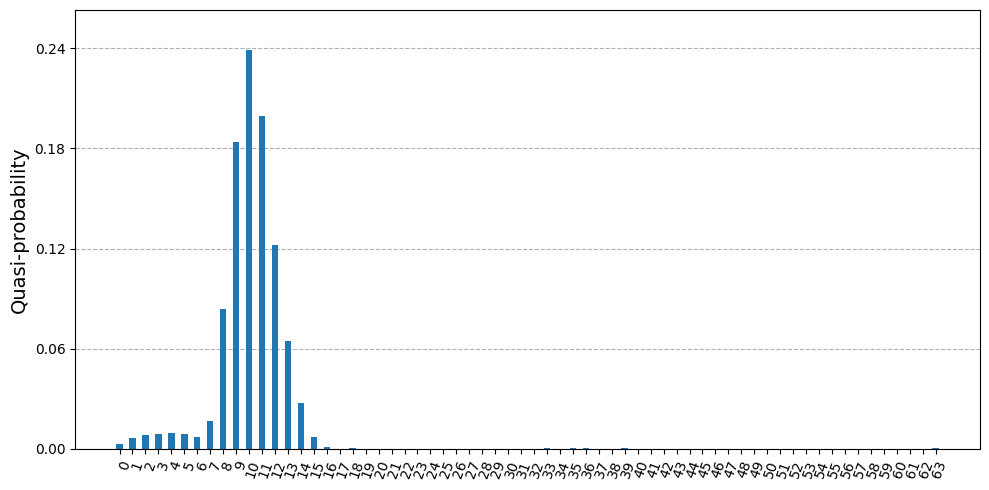

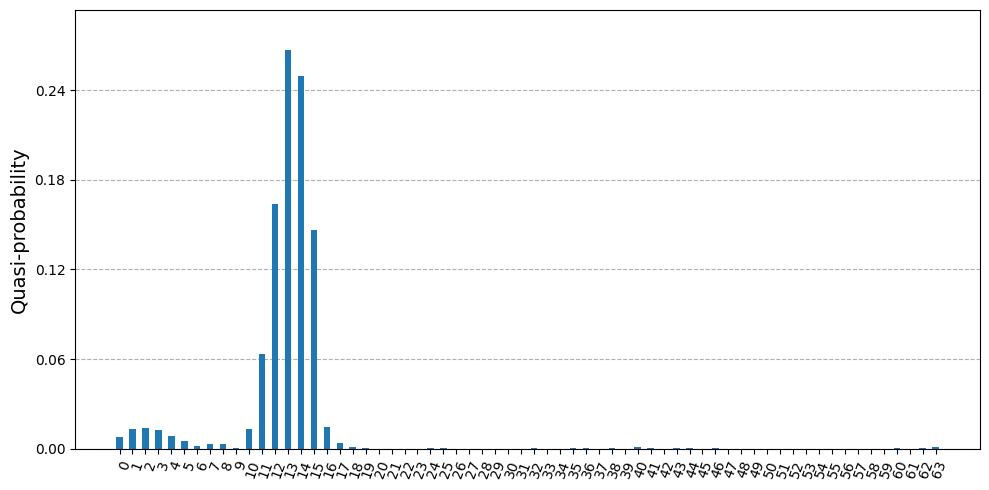

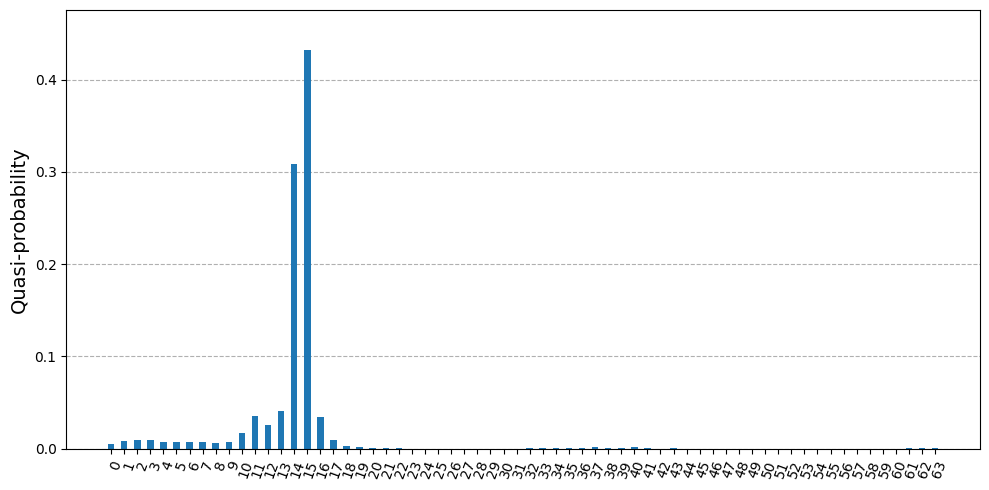

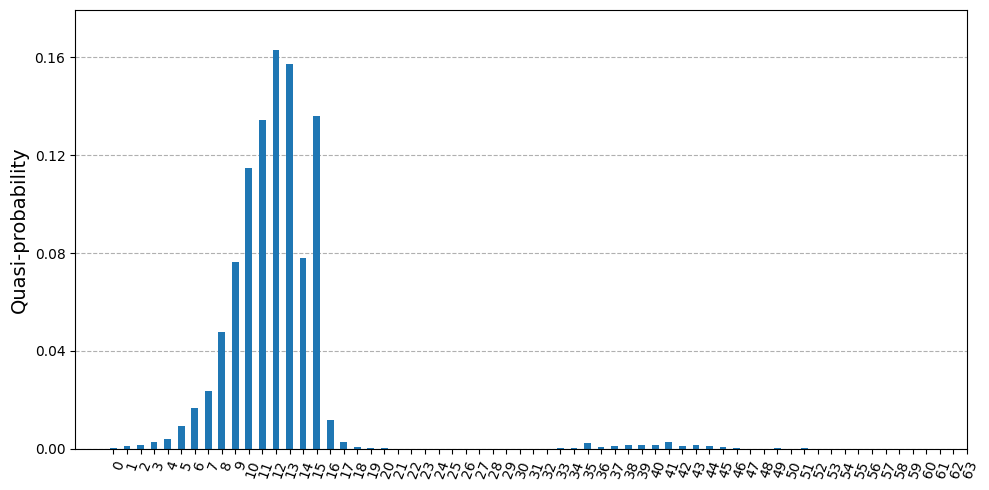

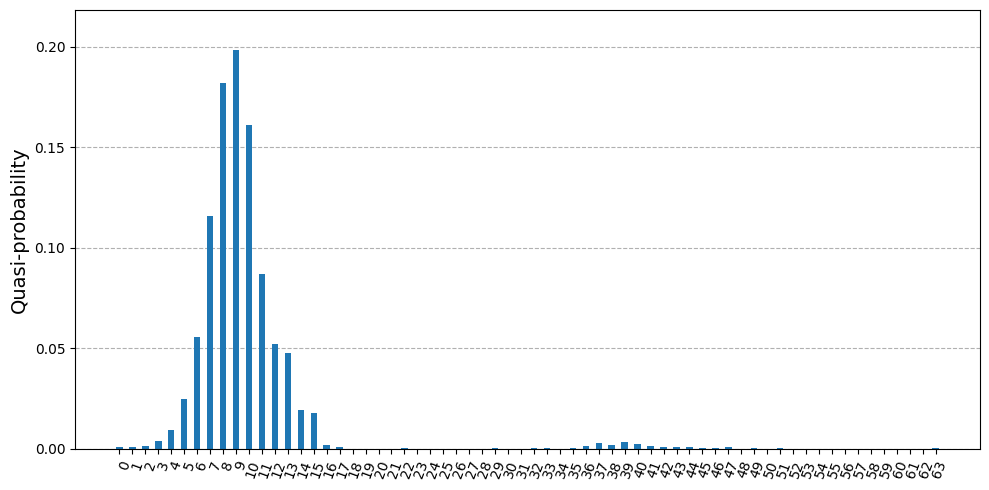

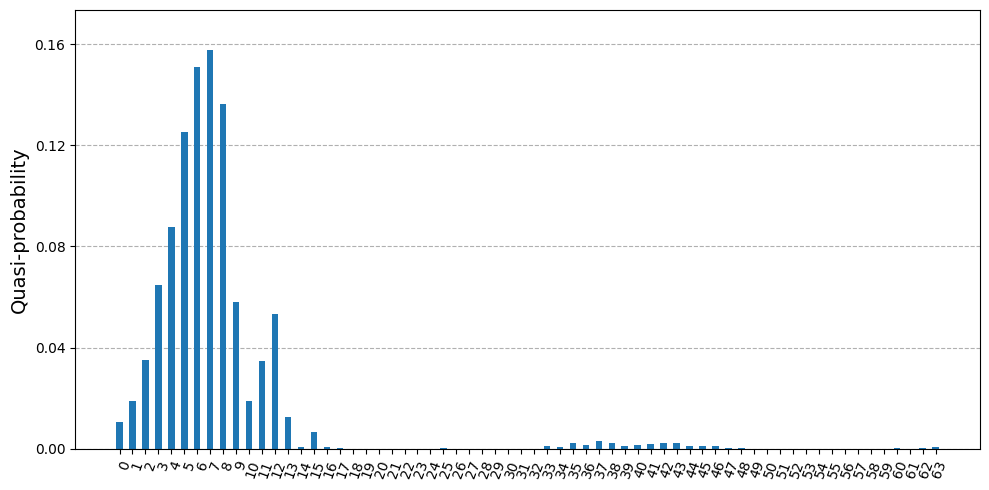

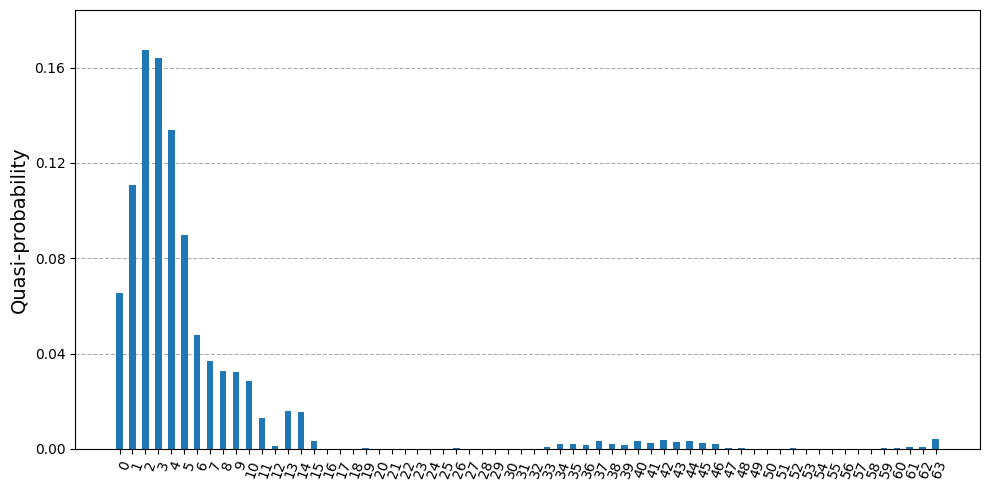

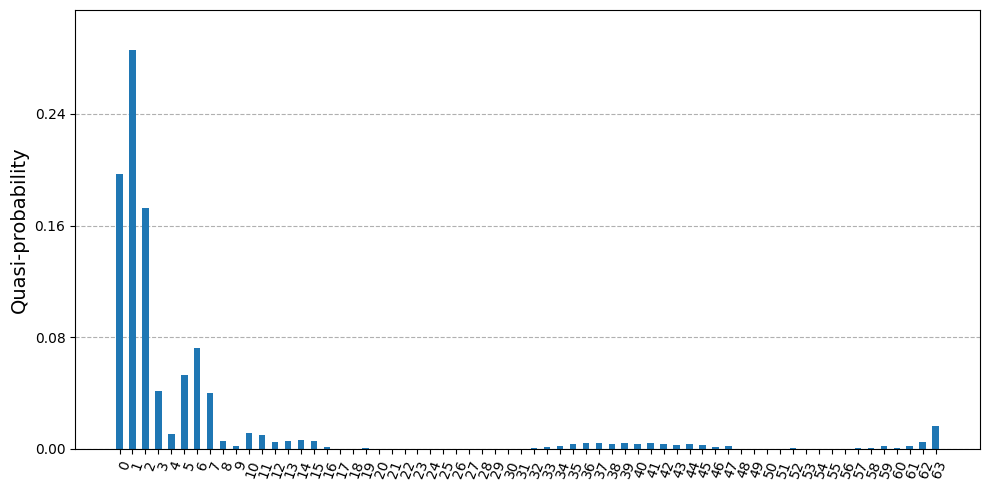

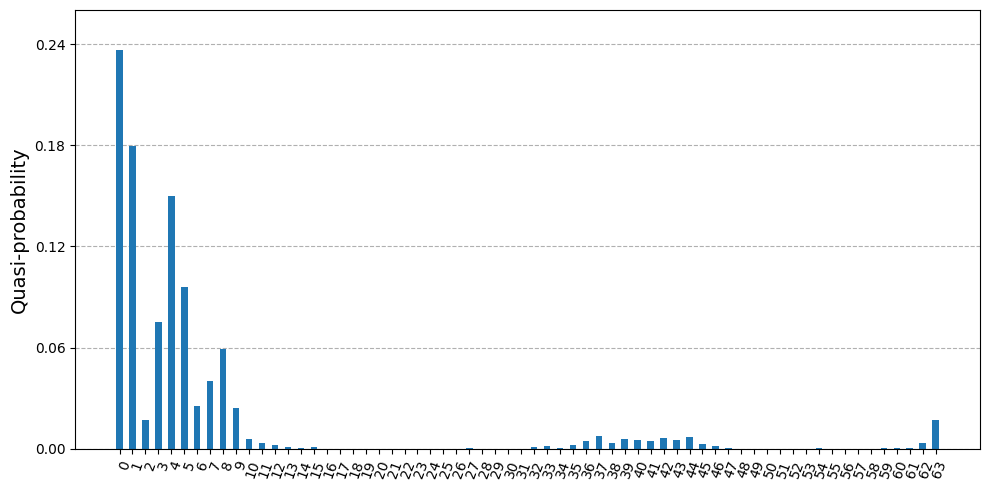

In [ ]:
x = np.linspace(-0.5,4, num=64)
'''wavefunction: guassian wavepacket with moving forward(+ve x axis) in time'''
x0=0
hk=-3
V=2
unnormalized_wavefunction= (1/(np.sqrt(2*np.pi)*0.4)*np.exp(-(0.5*(x-x0)**2)/(0.016)))*np.exp(300j*x)


Normalisation_Constant = np.sqrt(np.sum(np.abs(unnormalized_wavefunction**2)))

forward_wave = (unnormalized_wavefunction)/(Normalisation_Constant)


# plt.plot(x,forward_wave)
# plt.show()
def evolve(iter,wavefunction,n=6,plot=True,hist=True):
    phi = 0.1  # function of time step
    V=10
    q_reg=QuantumRegister(6)
    aux_reg=QuantumRegister(1)
    clas_reg = ClassicalRegister(6,'classical')
    qc=QuantumCircuit(aux_reg,q_reg,clas_reg)
    initialization(qc,wavefunction,q_reg)
    i=0
    snaps=[]
    for i in range(iter):
        qc.p(V*phi,4)

        # qc.ccx(4,3,0)
        # qc.cp(V*phi,0,5)
        # qc.ccx(4,3,0)

        # qc.cx(4,0)
        # qc.cp(V*phi,0,5)
        # qc.cx(4,0)

        apply_QFT(qc,q_reg,n) 
        qc.x(n)
        Time_Evolution(qc,n,q_reg,aux_reg)
        qc.x(n) 
        apply_invQFT(qc,q_reg,n)
        if i%5==0:
            snaps.append(qc.copy())
        i=i+1
    for snap in snaps:
        display_histogram(snap,q_reg,clas_reg,n,plot=plot,hist=hist,probabilities=True)


evolve(iter=50,wavefunction=forward_wave,n=6,plot=False,hist=True)

## Quantum Tunnelling


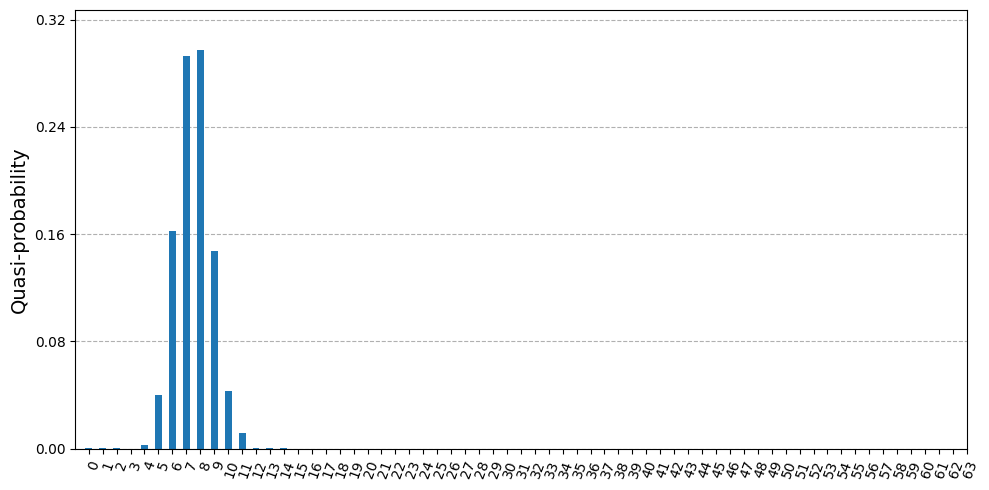

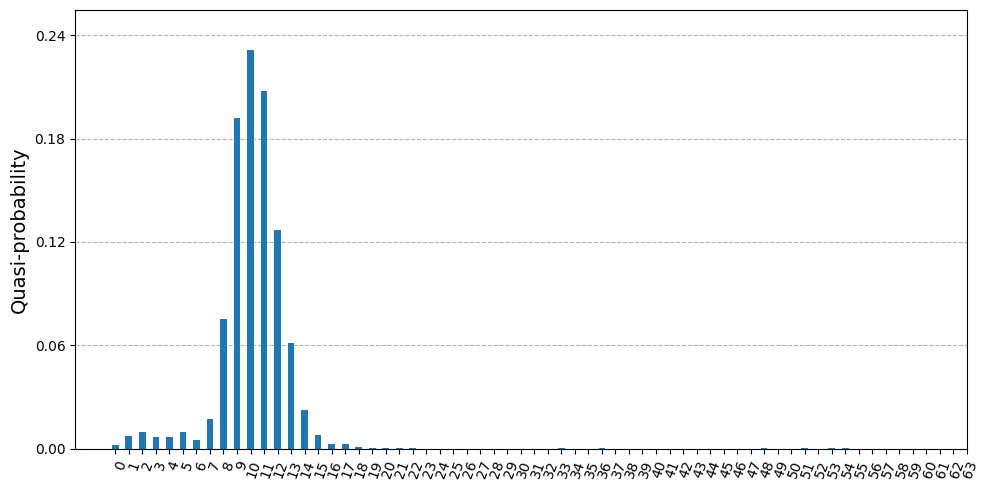

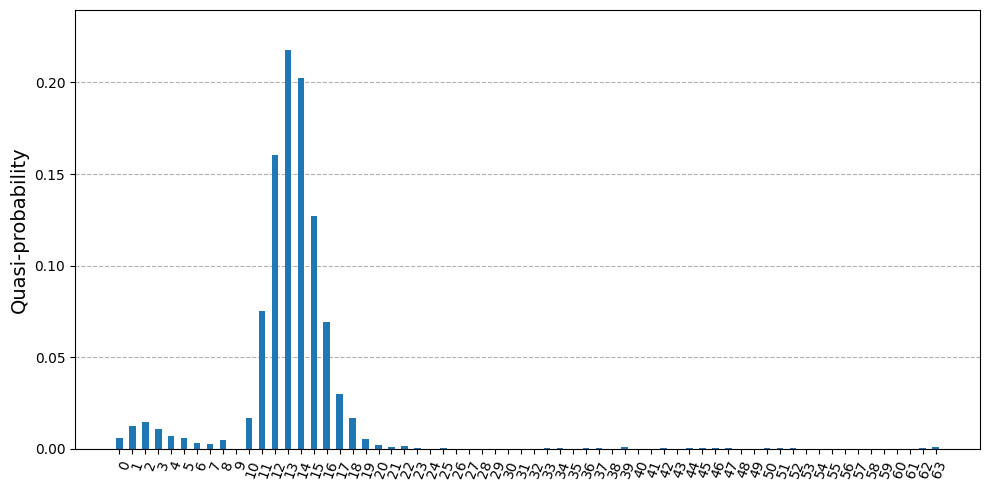

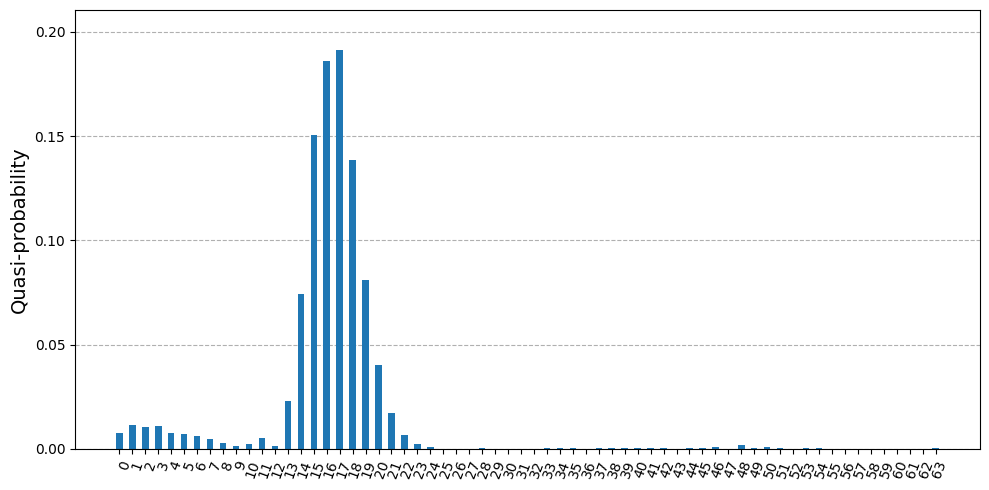

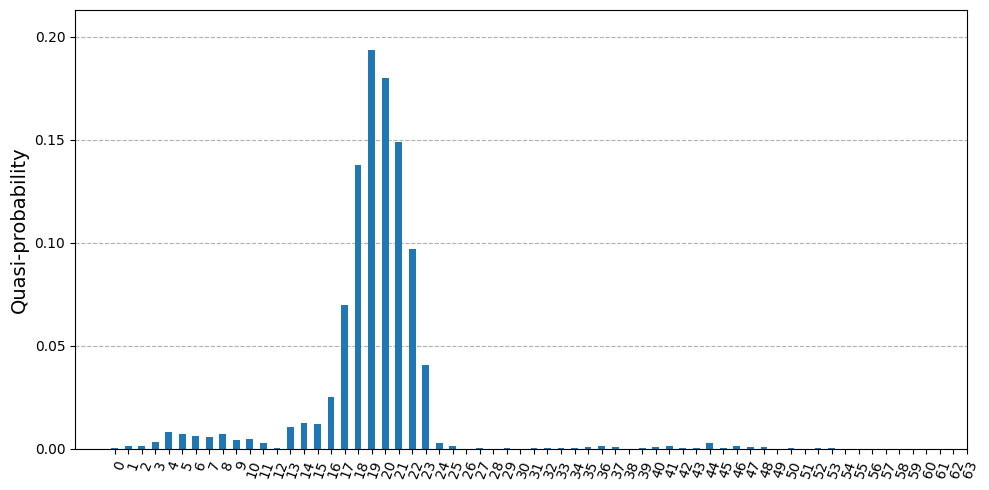

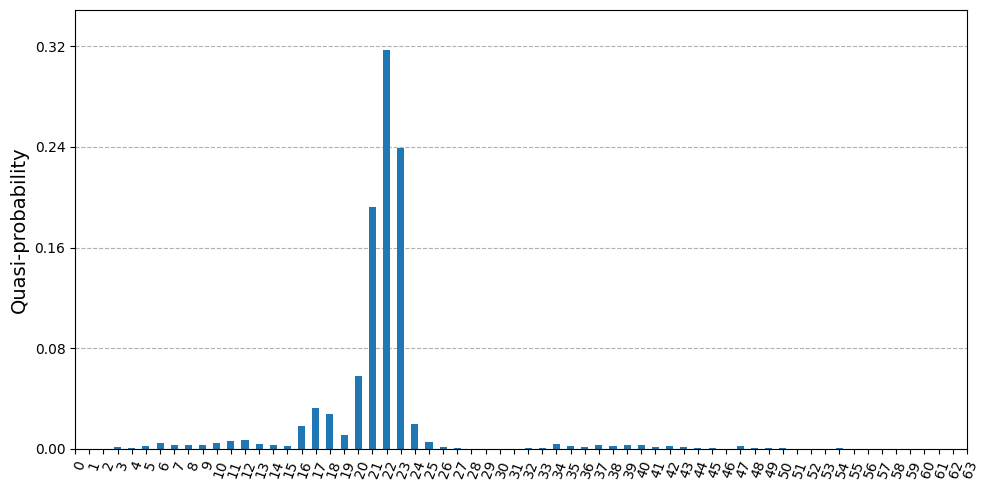

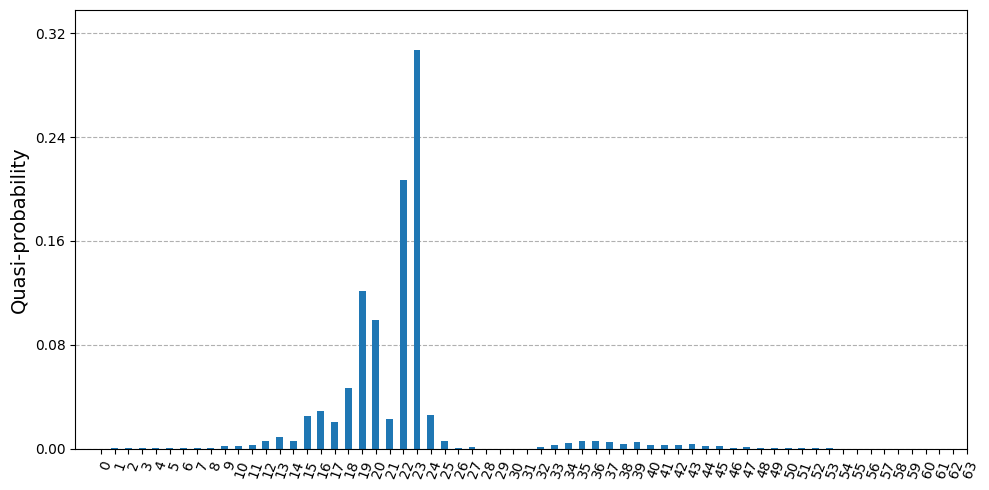

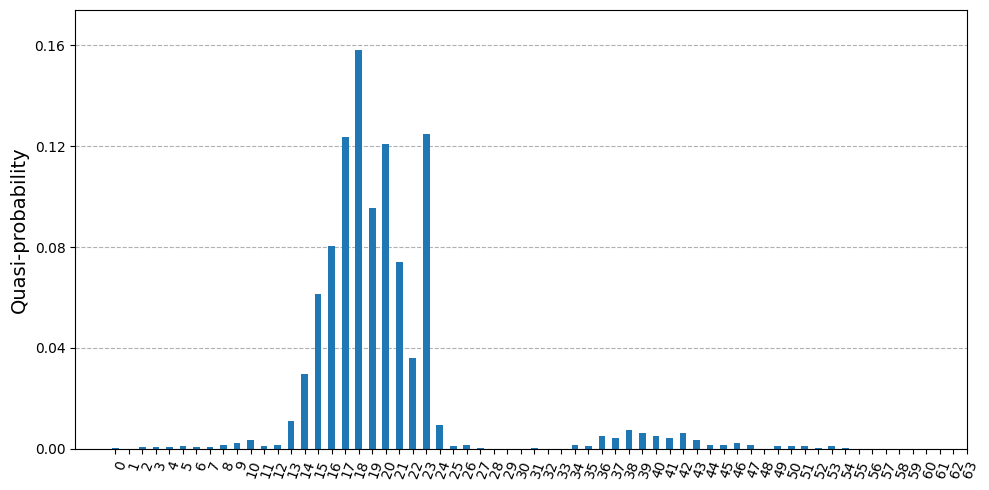

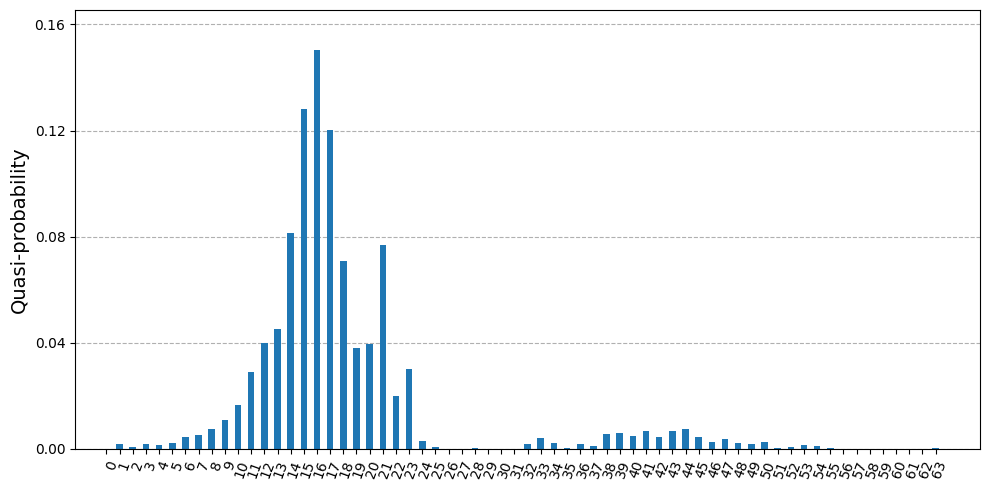

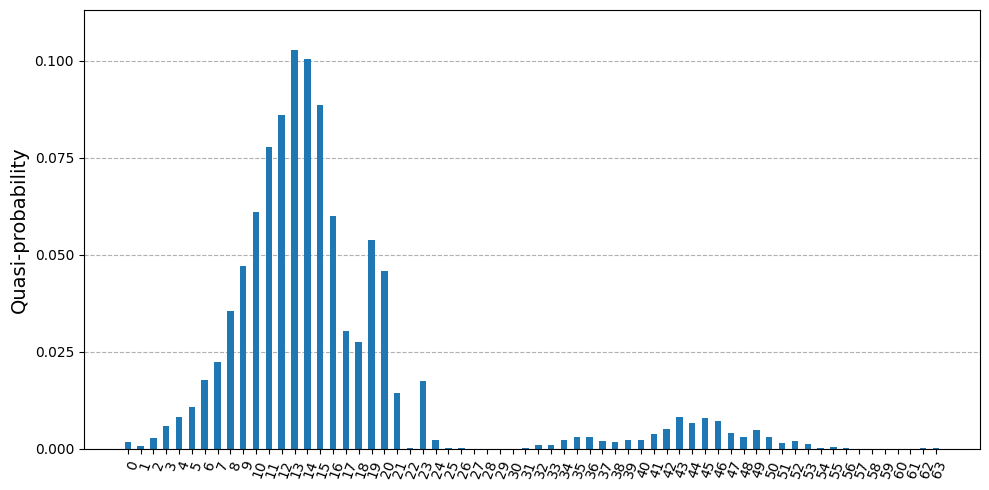

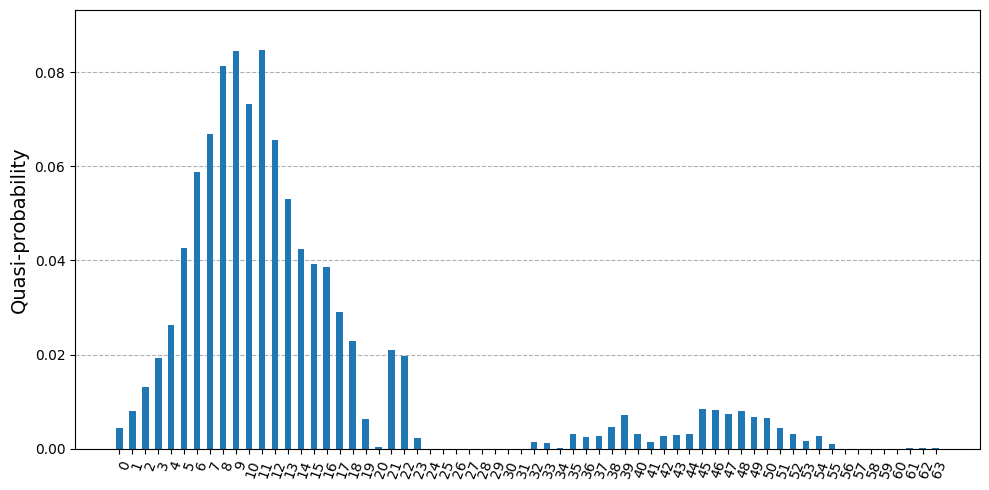

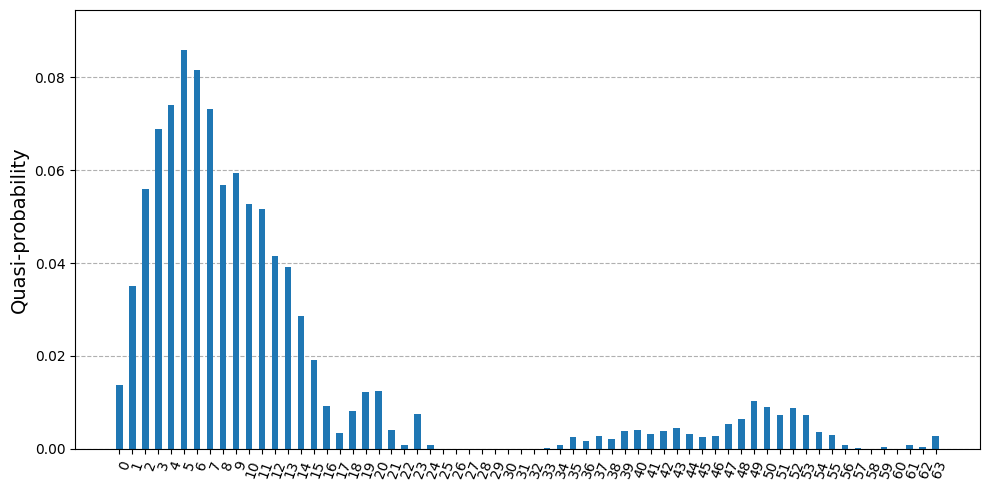

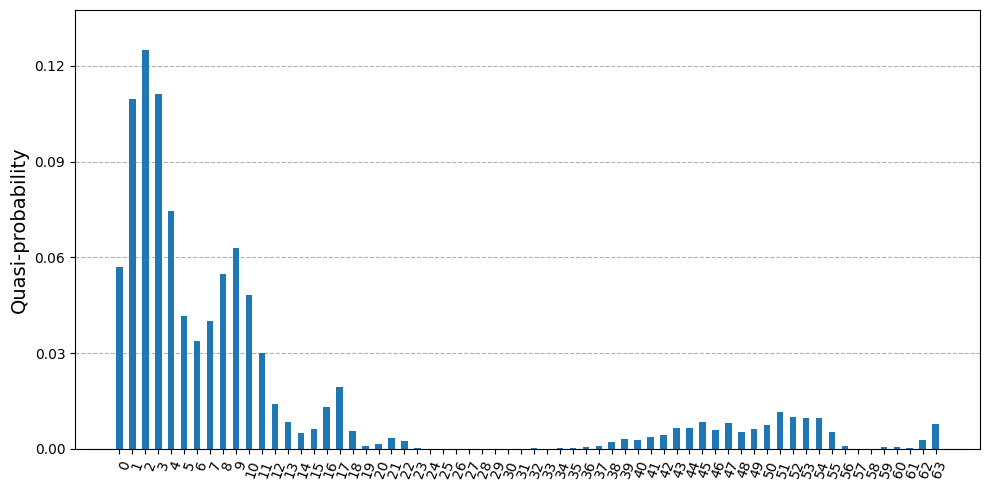

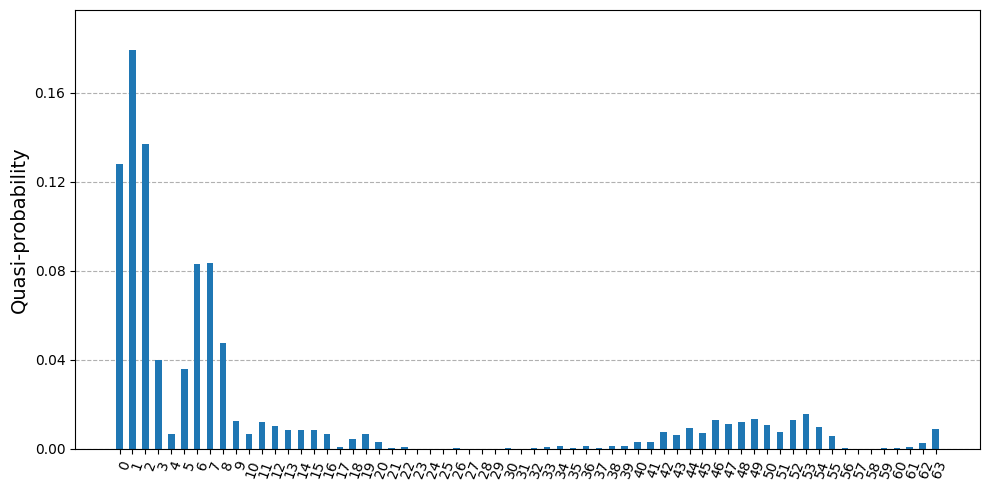

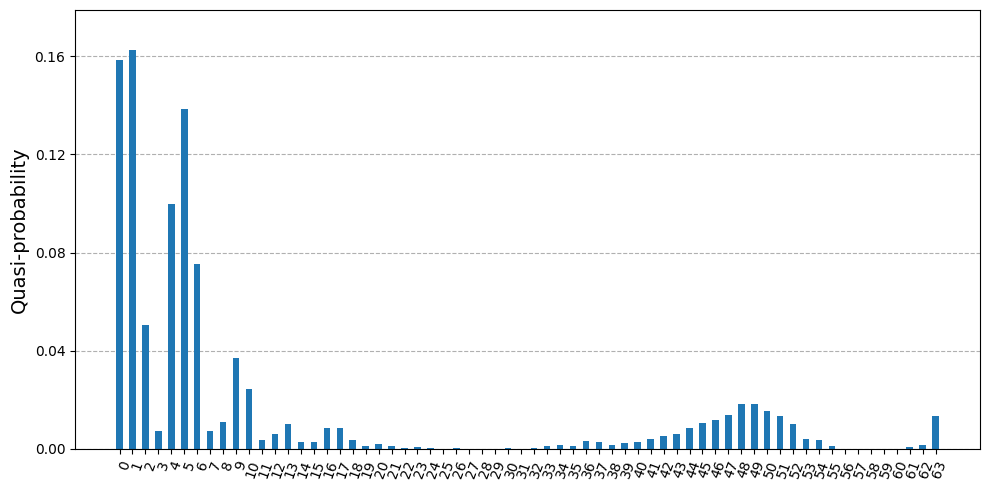

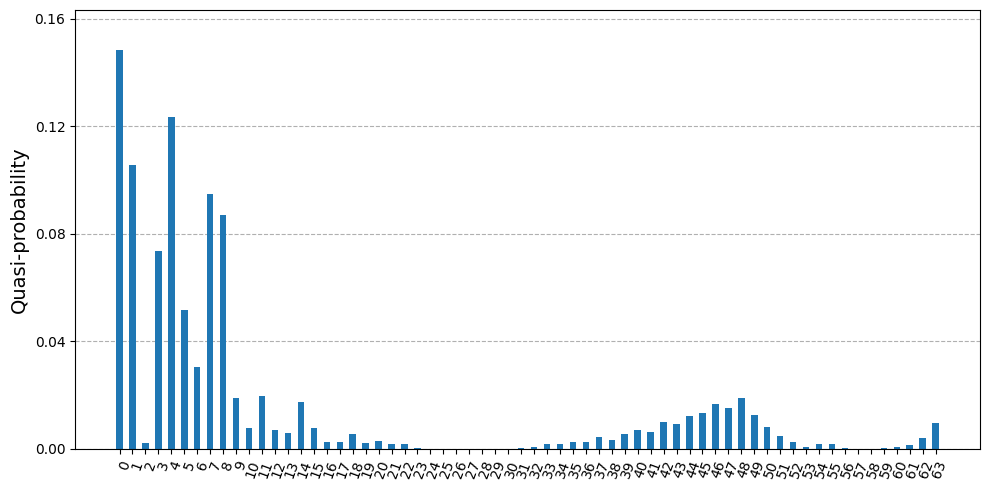

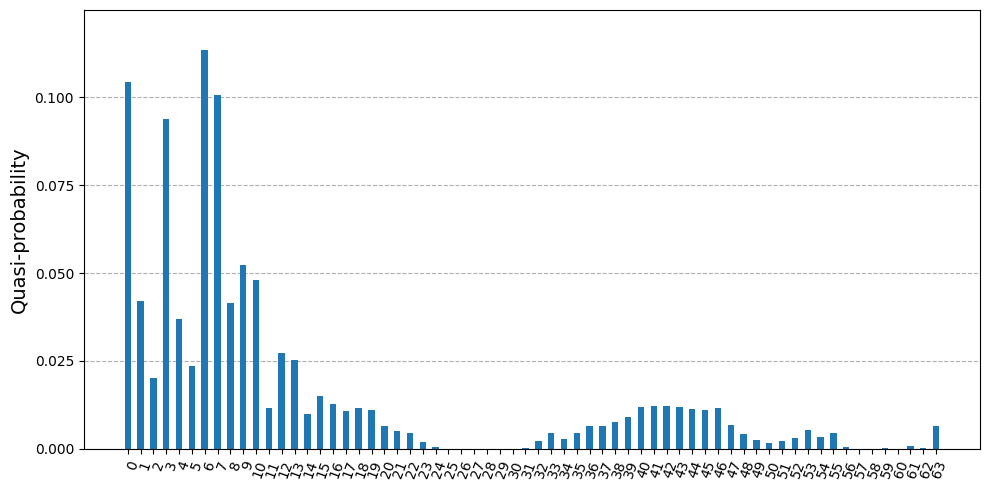

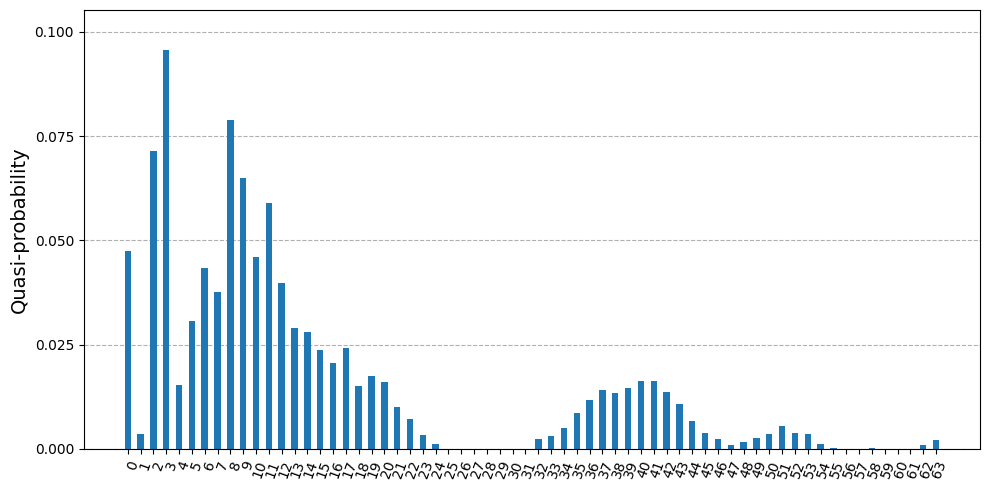

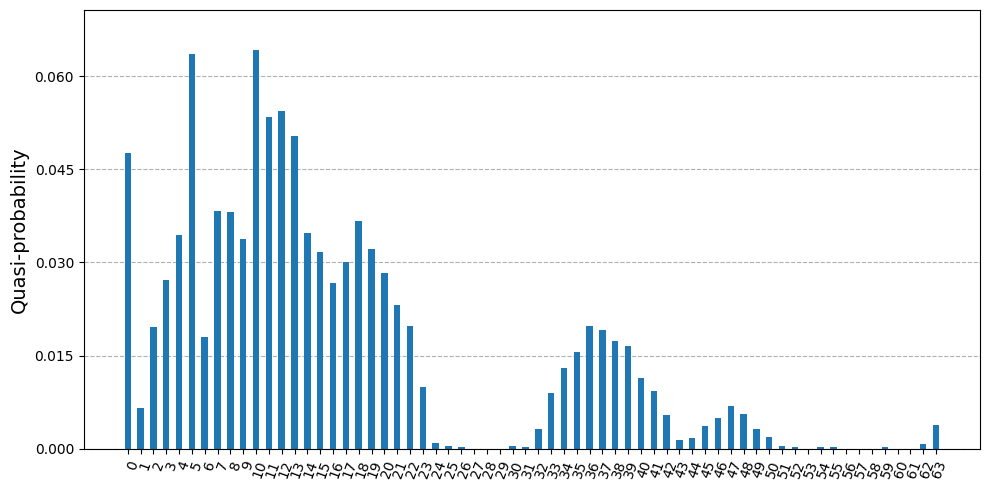

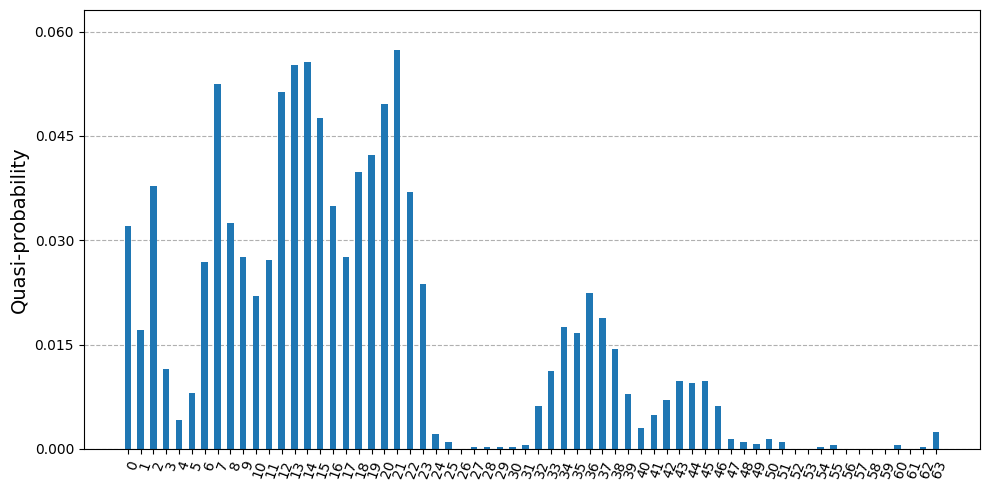

In [35]:
x = np.linspace(-0.5,4, num=64)
'''wavefunction: guassian wavepacket with moving forward(+ve x axis) in time'''
x0=0
hk=-3
V=1.7
unnormalized_wavefunction= (1/(np.sqrt(2*np.pi)*0.4)*np.exp(-(0.5*(x-x0)**2)/(0.016)))*np.exp(300j*x)


Normalisation_Constant = np.sqrt(np.sum(np.abs(unnormalized_wavefunction**2)))

forward_wave = (unnormalized_wavefunction)/(Normalisation_Constant)


# plt.plot(x,forward_wave)
# plt.show()
def evolve(iter,wavefunction,n=6,plot=True,hist=True):
    phi = 0.1  # function of time step
    V=10
    q_reg=QuantumRegister(6)
    aux_reg=QuantumRegister(1)
    clas_reg = ClassicalRegister(6,'classical')
    qc=QuantumCircuit(aux_reg,q_reg,clas_reg)
    initialization(qc,wavefunction,q_reg)
    i=0
    snaps=[]
    for i in range(iter):
        # qc.p(V*phi,4)

        # qc.ccx(4,3,0)
        # qc.cp(V*phi,0,5)
        # qc.ccx(4,3,0)

        qc.cx(4,0)
        qc.cp(V*phi,0,5)
        qc.cx(4,0)

        apply_QFT(qc,q_reg,n) 
        qc.x(n)
        Time_Evolution(qc,n,q_reg,aux_reg)
        qc.x(n) 
        apply_invQFT(qc,q_reg,n)
        if i%5==0:
            snaps.append(qc.copy())
        i=i+1
    for snap in snaps:
        display_histogram(snap,q_reg,clas_reg,n,plot=plot,hist=hist,probabilities=True)


evolve(iter=100,wavefunction=forward_wave,n=6,plot=False,hist=True)

In [ ]:
#add test code here
# --- IGNORE ---
print("Hello World")

Hello World


In [ ]:
import qiskit.version as version
print(version)


<module 'qiskit.version' from 'e:\\miniconda\\envs\\QGSS\\Lib\\site-packages\\qiskit\\version.py'>
